In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#importar o arquivo flights.csv como um dataframe
df_flights_raw = pd.read_csv('data/flights.csv', low_memory=False)

In [3]:
#analise inicial do dataframe
df_flights_raw.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Conte o número de linhas em que ARRIVAL_DELAY é positivo (> 0), ou seja, o número de voos atrasados.
num_arrival_delay_positive = (df_flights_raw['ARRIVAL_DELAY'] > 0).sum()
print(num_arrival_delay_positive)

2086896


In [5]:
#verificar quantos aeroportos distintos existem na coluna DESTINATION_AIRPORT
print(df_flights_raw['DESTINATION_AIRPORT'].nunique())
#verificar quantos aeroportos distintos existem na coluna ORIGIN_AIRPORT
print(df_flights_raw['ORIGIN_AIRPORT'].nunique())

629
628


In [6]:
#remocao experimental de colunas
columns_removida = ['YEAR', 'DAY', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ARRIVAL_TIME', 'SCHEDULED_DEPARTURE', 'TAXI_OUT', 'WHEELS_OFF', 'DEPARTURE_TIME', 'SCHEDULED_ARRIVAL', 'TAXI_IN']
df_flights_refined = df_flights_raw.drop(columns=columns_removida)

In [7]:
df_flights_refined.shape

(5819079, 20)

In [8]:
df_flights_refined.head()

,MONTH,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DEPARTURE_DELAY,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,1,4,AS,ANC,SEA,-11.0,205.0,194.0,169.0,1448,404.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,4,AA,LAX,PBI,-8.0,280.0,279.0,263.0,2330,737.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,1,4,US,SFO,CLT,-2.0,286.0,293.0,266.0,2296,800.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,AA,LAX,MIA,-5.0,285.0,281.0,258.0,2342,748.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,1,4,AS,SEA,ANC,-1.0,235.0,215.0,199.0,1448,254.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df_flights_refined['CANCELLED'].unique()

array([0, 1])

In [10]:
# Filtra os voos cancelados
cancelled_flights = df_flights_refined[df_flights_refined['CANCELLED'] == 1]

# Mostra primeiros exemplos de voos cancelados para depuração
print(f"Número de voos cancelados: {cancelled_flights.shape[0]}")

# Verifica a existência de valores em 'ARRIVAL_DELAY'
print("Valores únicos em 'ARRIVAL_DELAY' para voos cancelados:", cancelled_flights['ARRIVAL_DELAY'].unique())


Número de voos cancelados: 89884
Valores únicos em 'ARRIVAL_DELAY' para voos cancelados: [nan]


In [11]:
# Remove as linhas em que a coluna 'CANCELLED' possui valor 1
df_flights_refined = df_flights_refined[df_flights_refined['CANCELLED'] != 1]

In [12]:
# Remove a coluna 'CANCELLED' pois todos os seus valores são iguais e a coluna 'CANCELLATION_REASON' pois não temos mais voos cancelados
df_flights_refined = df_flights_refined.drop(columns=['CANCELLED'])
df_flights_refined = df_flights_refined.drop(columns=['CANCELLATION_REASON'])

In [13]:
df_flights_refined.head()

,MONTH,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DEPARTURE_DELAY,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,ARRIVAL_DELAY,DIVERTED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,1,4,AS,ANC,SEA,-11.0,205.0,194.0,169.0,1448,404.0,-22.0,0,NaN,NaN,NaN,NaN,NaN
1,1,4,AA,LAX,PBI,-8.0,280.0,279.0,263.0,2330,737.0,-9.0,0,NaN,NaN,NaN,NaN,NaN
2,1,4,US,SFO,CLT,-2.0,286.0,293.0,266.0,2296,800.0,5.0,0,NaN,NaN,NaN,NaN,NaN
3,1,4,AA,LAX,MIA,-5.0,285.0,281.0,258.0,2342,748.0,-9.0,0,NaN,NaN,NaN,NaN,NaN
4,1,4,AS,SEA,ANC,-1.0,235.0,215.0,199.0,1448,254.0,-21.0,0,NaN,NaN,NaN,NaN,NaN


In [14]:
df_flights_refined.shape

(5729195, 18)

In [15]:
# Vamos ver o número de ocorrências onde os delays possuem valor (não nulo) e se eles são maioria atrasados ou adiantados
delay_columns = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
for col in delay_columns:
    notna_mask = df_flights_refined[col].notna()
    num_delay = notna_mask.sum()
    arrival_delays = df_flights_refined.loc[notna_mask, 'ARRIVAL_DELAY']
    num_positive = (arrival_delays > 0).sum()
    num_negative = (arrival_delays < 0).sum()
    print(f"Número de ocorrências com valor em '{col}': {num_delay}")
    print(f"  ARRIVAL_DELAY atrasados: {num_positive}")
    print(f"  ARRIVAL_DELAY adiantados: {num_negative}")
    if num_positive > num_negative:
        print("  A maioria dos ARRIVAL_DELAY são atrasados nesta coluna.")
    elif num_negative > num_positive:
        print("  A maioria dos ARRIVAL_DELAY são adiantados nesta coluna.")
    else:
        print("  Quantidade igual de ARRIVAL_DELAY atrasados e adiantados nesta coluna (ou nenhum valor distinto).")
    print()

Número de ocorrências com valor em 'AIR_SYSTEM_DELAY': 1063439
  ARRIVAL_DELAY atrasados: 1063439
  ARRIVAL_DELAY adiantados: 0
  A maioria dos ARRIVAL_DELAY são atrasados nesta coluna.

Número de ocorrências com valor em 'SECURITY_DELAY': 1063439
  ARRIVAL_DELAY atrasados: 1063439
  ARRIVAL_DELAY adiantados: 0
  A maioria dos ARRIVAL_DELAY são atrasados nesta coluna.

Número de ocorrências com valor em 'AIRLINE_DELAY': 1063439
  ARRIVAL_DELAY atrasados: 1063439
  ARRIVAL_DELAY adiantados: 0
  A maioria dos ARRIVAL_DELAY são atrasados nesta coluna.

Número de ocorrências com valor em 'LATE_AIRCRAFT_DELAY': 1063439
  ARRIVAL_DELAY atrasados: 1063439
  ARRIVAL_DELAY adiantados: 0
  A maioria dos ARRIVAL_DELAY são atrasados nesta coluna.

Número de ocorrências com valor em 'WEATHER_DELAY': 1063439
  ARRIVAL_DELAY atrasados: 1063439
  ARRIVAL_DELAY adiantados: 0
  A maioria dos ARRIVAL_DELAY são atrasados nesta coluna.



In [16]:
#podemos presumir que sempre que uma dessas colunas possui valor, o voo foi atrasado
#portanto vamos eliminar essas colunas e manter o foco em descobrir se o existem outras causas de atraso
df_flights_refined = df_flights_refined.drop(columns=['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'])
df_flights_refined.shape
df_flights_refined.head()


,MONTH,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DEPARTURE_DELAY,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,ARRIVAL_DELAY,DIVERTED,AIRLINE_DELAY
0,1,4,AS,ANC,SEA,-11.0,205.0,194.0,169.0,1448,404.0,-22.0,0,NaN
1,1,4,AA,LAX,PBI,-8.0,280.0,279.0,263.0,2330,737.0,-9.0,0,NaN
2,1,4,US,SFO,CLT,-2.0,286.0,293.0,266.0,2296,800.0,5.0,0,NaN
3,1,4,AA,LAX,MIA,-5.0,285.0,281.0,258.0,2342,748.0,-9.0,0,NaN
4,1,4,AS,SEA,ANC,-1.0,235.0,215.0,199.0,1448,254.0,-21.0,0,NaN


In [17]:
#vamos comparar as colunas que tiramos do arquivo original com os atrasos para tentar achar uma relação entre aeroportos e companhias
# descobrir se essas ocorrencias são devidos as empresas ou aos locais
# Selecionando as colunas excluídas ao longo do script e outras de interesse
removed_columns = [
    'CANCELLED',
    'CANCELLATION_REASON',
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]
columns_of_interest = removed_columns + ['ARRIVAL_DELAY', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']

# Seleciona do DataFrame original as colunas necessárias
df_selected = df_flights_raw[columns_of_interest].copy()


In [18]:
# Para as colunas removidas (índices 5 a 11 em removed_columns), vamos identificar linhas onde essas colunas NÃO são NaN,
# e contar as ocorrências de cada AIRLINE, ORIGIN_AIRPORT e DESTINATION_AIRPORT nesses casos.

delay_cols = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]

# Máscara: pelo menos uma dessas colunas NÃO é NaN (indicando presença de atraso específico)
has_delay_cause = df_selected[delay_cols].notna().any(axis=1)

# Filtra o DataFrame para essas ocorrências
df_delay_cause = df_selected.loc[has_delay_cause]

# Conta as ocorrências de AIRLINE, ORIGIN_AIRPORT e DESTINATION_AIRPORT nesse subconjunto (com causa de atraso)
airline_counts = df_delay_cause['AIRLINE'].value_counts()
origin_counts = df_delay_cause['ORIGIN_AIRPORT'].value_counts()
destination_counts = df_delay_cause['DESTINATION_AIRPORT'].value_counts()

# Agora, vamos contar o número total de voos (todas as linhas) para cada companhia e cada aeroporto
total_airline_counts = df_selected['AIRLINE'].value_counts()
total_origin_counts = df_selected['ORIGIN_AIRPORT'].value_counts()
total_destination_counts = df_selected['DESTINATION_AIRPORT'].value_counts()

print("Ocorrências de AIRLINE (quando algum dos motivos de atraso está presente):")
print(airline_counts.head(10))
print("\nTotal de voos por AIRLINE:")
print(total_airline_counts.head(10))
print("\nPercentual de voos com atraso por AIRLINE:")
percent_airline = (airline_counts / total_airline_counts * 100).sort_values(ascending=False)
print(percent_airline.head(10).round(2))

print("\nOcorrências de ORIGIN_AIRPORT (quando algum dos motivos de atraso está presente):")
print(origin_counts.head(10))
print("\nTotal de voos por ORIGIN_AIRPORT:")
print(total_origin_counts.head(10))
print("\nPercentual de voos com atraso por ORIGIN_AIRPORT:")
percent_origin = (origin_counts / total_origin_counts * 100).sort_values(ascending=False)
print(percent_origin.head(10).round(2))

print("\nOcorrências de DESTINATION_AIRPORT (quando algum dos motivos de atraso está presente):")
print(destination_counts.head(10))
print("\nTotal de voos por DESTINATION_AIRPORT:")
print(total_destination_counts.head(10))
print("\nPercentual de voos com atraso por DESTINATION_AIRPORT:")
percent_destination = (destination_counts / total_destination_counts * 100).sort_values(ascending=False)
print(percent_destination.head(10).round(2))

Ocorrências de AIRLINE (quando algum dos motivos de atraso está presente):
AIRLINE
WN    236626
AA    130279
DL    118023
EV    109184
OO    107795
UA    104722
MQ     60547
B6     59175
US     36549
NK     34221
Name: count, dtype: int64

Total de voos por AIRLINE:
AIRLINE
WN    1261855
DL     875881
AA     725984
OO     588353
EV     571977
UA     515723
MQ     294632
B6     267048
US     198715
AS     172521
Name: count, dtype: int64

Percentual de voos com atraso por AIRLINE:
AIRLINE
NK    29.15
F9    25.95
B6    22.16
MQ    20.55
UA    20.31
EV    19.09
VX    19.03
WN    18.75
US    18.39
OO    18.32
Name: count, dtype: float64

Ocorrências de ORIGIN_AIRPORT (quando algum dos motivos de atraso está presente):
ORIGIN_AIRPORT
ORD    66663
ATL    56462
DFW    50478
DEN    43331
LAX    40281
IAH    30690
SFO    29534
PHX    27427
LAS    27225
LGA    22709
Name: count, dtype: int64

Total de voos por ORIGIN_AIRPORT:
ORIGIN_AIRPORT
ATL    346836
ORD    285884
DFW    239551
DEN    196055

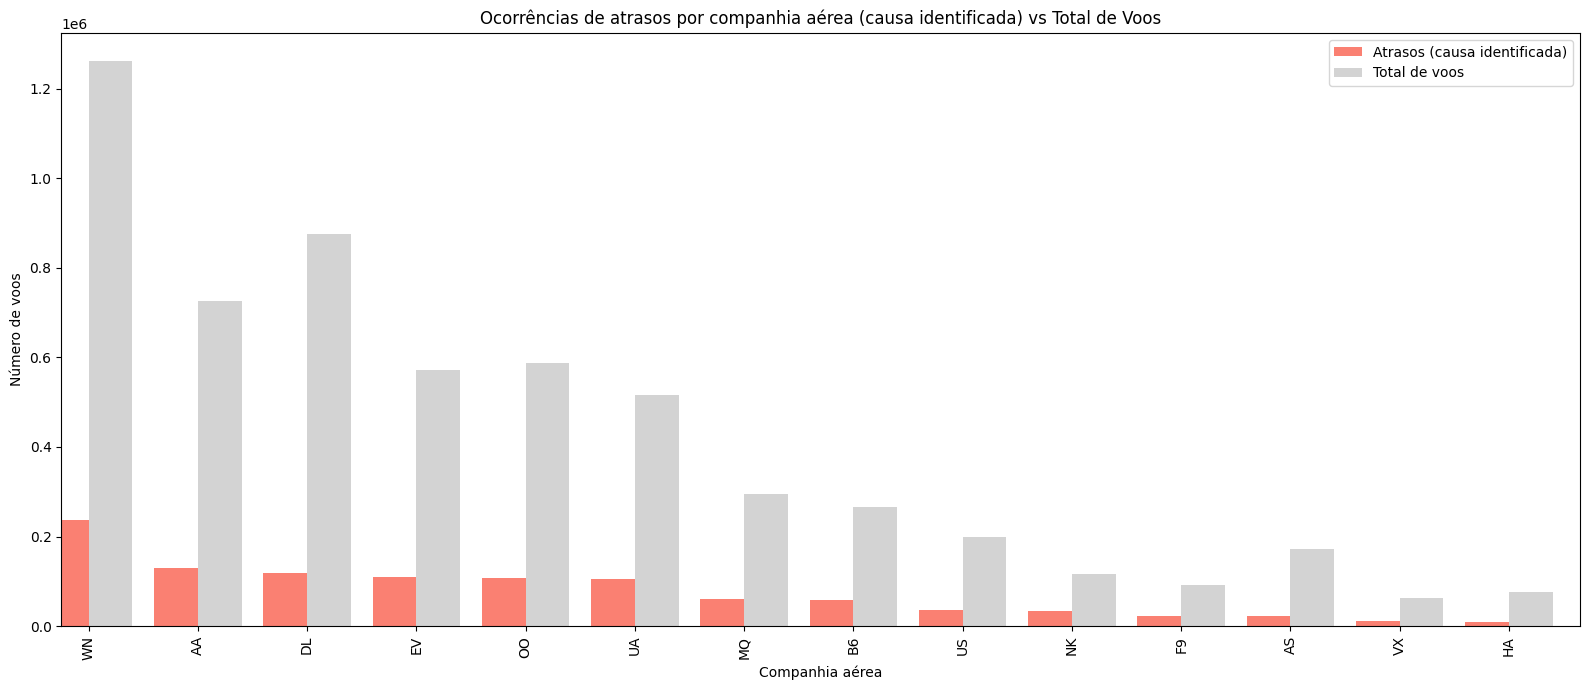

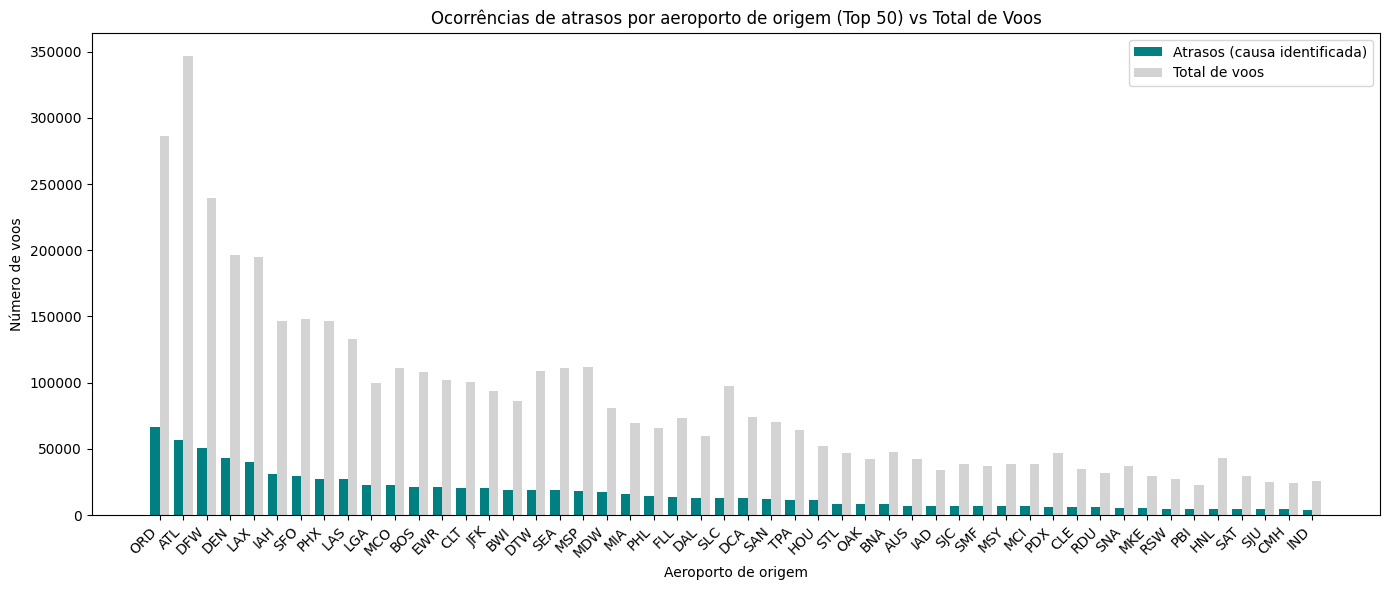

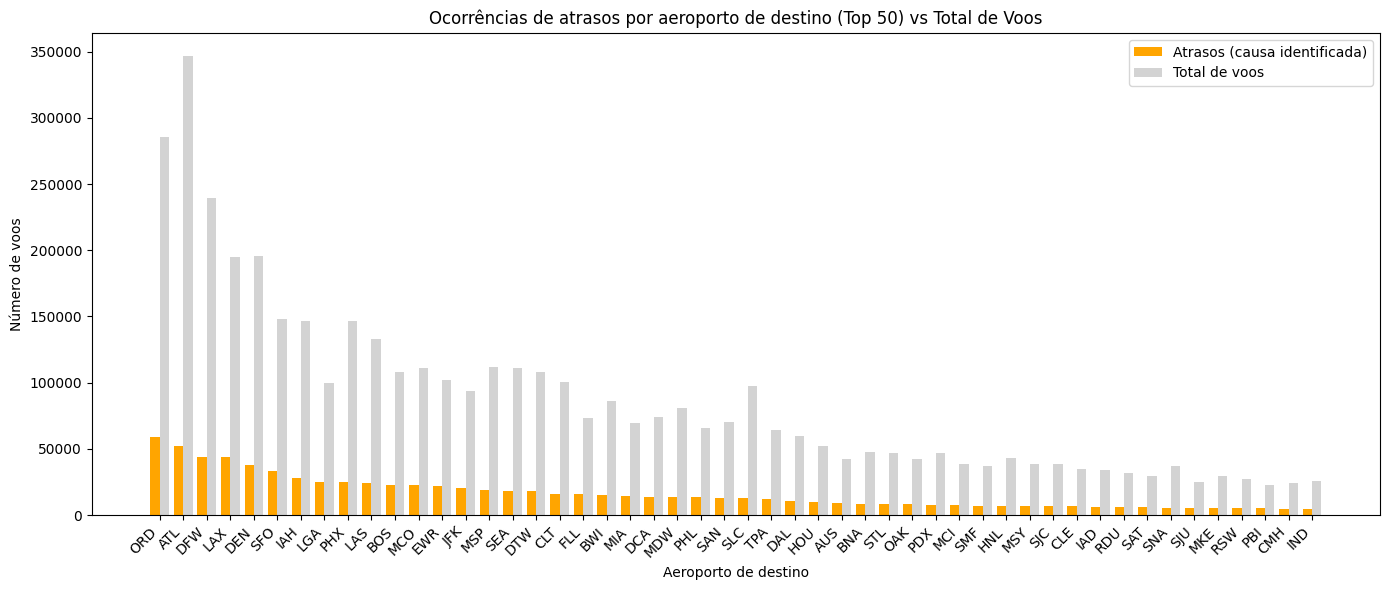

In [19]:
# --- Companhia aérea: atrasos (causa identificada) vs Total de voos ---
plt.figure(figsize=(16, 7))
ax = airline_counts.plot(kind='bar', color='salmon', width=0.4, position=1, label='Atrasos (causa identificada)')
total_airline_counts.loc[airline_counts.index].plot(kind='bar', color='lightgrey', width=0.4, position=0, label='Total de voos', ax=ax)
plt.title('Ocorrências de atrasos por companhia aérea (causa identificada) vs Total de Voos')
plt.xlabel('Companhia aérea')
plt.ylabel('Número de voos')
plt.legend()
plt.tight_layout()
plt.show()

# --- Aeroporto de origem: visualização aprimorada ---
# Exibir somente os 20 aeroportos de origem com mais ocorrências de atrasos com causa identificada (torna o gráfico legível)
top_n = 50
top_origin = origin_counts.nlargest(top_n)
top_origin_total = total_origin_counts.loc[top_origin.index]

plt.figure(figsize=(14, 6))
bar_width = 0.4
positions = np.arange(top_n)

plt.bar(positions - bar_width/2, top_origin.values, width=bar_width, color='teal', label='Atrasos (causa identificada)')
plt.bar(positions + bar_width/2, top_origin_total.values, width=bar_width, color='lightgrey', label='Total de voos')
plt.title(f'Ocorrências de atrasos por aeroporto de origem (Top {top_n}) vs Total de Voos')
plt.xlabel('Aeroporto de origem')
plt.ylabel('Número de voos')
plt.xticks(positions, top_origin.index, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# --- Aeroporto de destino: visualização aprimorada ---
# Exibir somente os 20 aeroportos de destino com mais ocorrências de atrasos com causa identificada (torna o gráfico legível)
top_dest = destination_counts.nlargest(top_n)
top_dest_total = total_destination_counts.loc[top_dest.index]

plt.figure(figsize=(14, 6))
positions_dest = np.arange(top_n)

plt.bar(positions_dest - bar_width/2, top_dest.values, width=bar_width, color='orange', label='Atrasos (causa identificada)')
plt.bar(positions_dest + bar_width/2, top_dest_total.values, width=bar_width, color='lightgrey', label='Total de voos')
plt.title(f'Ocorrências de atrasos por aeroporto de destino (Top {top_n}) vs Total de Voos')
plt.xlabel('Aeroporto de destino')
plt.ylabel('Número de voos')
plt.xticks(positions_dest, top_dest.index, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Criação de DataFrames com informações numéricas para análise de atrasos

# Companhias Aéreas: Ocorrências de atrasos com causa identificada e porcentagens
airline_info_df = pd.DataFrame({
    "Atrasos_causa_identificada": airline_counts,
    "Total_de_voos": total_airline_counts.loc[airline_counts.index],
})
airline_info_df["Porcentagem_atrasos_(%)"] = (
    airline_info_df["Atrasos_causa_identificada"] / airline_info_df["Total_de_voos"] * 100
).round(2)
# Ordenar do maior para o menor pela porcentagem de atrasos
airline_info_df = airline_info_df.sort_values(by="Porcentagem_atrasos_(%)", ascending=False)
display(airline_info_df)

# Aeroportos de Origem: Top 50, Ocorrências de atrasos c/ causa identificada e porcentagens
origin_info_df = pd.DataFrame({
    "Atrasos_causa_identificada": top_origin,
    "Total_de_voos": top_origin_total,
})
origin_info_df["Porcentagem_atrasos_(%)"] = (
    origin_info_df["Atrasos_causa_identificada"] / origin_info_df["Total_de_voos"] * 100
).round(2)
origin_info_df = origin_info_df.sort_values(by="Porcentagem_atrasos_(%)", ascending=False)
display(origin_info_df)

# Aeroportos de Destino: Top 50, Ocorrências de atrasos c/ causa identificada e porcentagens
destination_info_df = pd.DataFrame({
    "Atrasos_causa_identificada": top_dest,
    "Total_de_voos": top_dest_total,
})
destination_info_df["Porcentagem_atrasos_(%)"] = (
    destination_info_df["Atrasos_causa_identificada"] / destination_info_df["Total_de_voos"] * 100
).round(2)
destination_info_df = destination_info_df.sort_values(by="Porcentagem_atrasos_(%)", ascending=False)
display(destination_info_df)

,Atrasos_causa_identificada,Total_de_voos,Porcentagem_atrasos_(%)
AIRLINE,,,
NK,34221,117379,29.15
F9,23570,90836,25.95
B6,59175,267048,22.16
MQ,60547,294632,20.55
UA,104722,515723,20.31
EV,109184,571977,19.09
VX,11778,61903,19.03
WN,236626,1261855,18.75
US,36549,198715,18.39


,Atrasos_causa_identificada,Total_de_voos,Porcentagem_atrasos_(%)
ORIGIN_AIRPORT,,,
ORD,66663,285884,23.32
LGA,22709,99605,22.80
MIA,15785,69341,22.76
BWI,19049,86079,22.13
DEN,43331,196055,22.10
DAL,13176,59699,22.07
JFK,20260,93811,21.60
PHL,14173,66021,21.47
HOU,11138,52042,21.40


,Atrasos_causa_identificada,Total_de_voos,Porcentagem_atrasos_(%)
DESTINATION_AIRPORT,,,
LGA,24819,99581,24.92
PBI,5142,22574,22.78
SJU,5521,24653,22.39
LAX,43453,194696,22.32
SFO,32984,147966,22.29
EWR,22051,101830,21.65
JFK,20294,93809,21.63
FLL,15620,73599,21.22
BOS,22775,107851,21.12


In [21]:
# Seleciona todos os voos com atraso (ARRIVAL_DELAY > 0)
df_atrasados = df_flights_raw[df_flights_raw['ARRIVAL_DELAY'] > 0]

# Conta o número total de atrasos em que o aeroporto aparece como ORIGIN_AIRPORT
atrasos_por_origem = df_atrasados['ORIGIN_AIRPORT'].value_counts()

# Conta o número total de atrasos em que o aeroporto aparece como DESTINATION_AIRPORT
atrasos_por_destino = df_atrasados['DESTINATION_AIRPORT'].value_counts()

# Soma ambos para obter o total de atrasos onde o aeroporto esteve envolvido como origem ou destino
atrasos_total_por_aeroporto = atrasos_por_origem.add(atrasos_por_destino, fill_value=0).astype(int)

# Ordena do maior para o menor número de atrasos
atrasos_total_por_aeroporto = atrasos_total_por_aeroporto.sort_values(ascending=False)

# Mostra os aeroportos com mais atrasos
# Primeiro, conte o total de voos (chegada ou saída) por aeroporto
total_voos_por_aeroporto = (
    df_flights_raw['ORIGIN_AIRPORT'].value_counts() + 
    df_flights_raw['DESTINATION_AIRPORT'].value_counts()
)

# Calcula a porcentagem de atrasos em relação ao total de voos (chegada ou saída)
porcentagem_atrasos_por_aeroporto = (
    atrasos_total_por_aeroporto / total_voos_por_aeroporto.loc[atrasos_total_por_aeroporto.index]
) * 100

# Cria um DataFrame para visualização clara
df_atrasos_porcentagem = pd.DataFrame({
    'Total_de_Atrasos': atrasos_total_por_aeroporto,
    'Total_de_Voos': total_voos_por_aeroporto.loc[atrasos_total_por_aeroporto.index],
    'Porcentagem_de_Atrasos(%)': porcentagem_atrasos_por_aeroporto.round(2)
})

# Mostra os 50 aeroportos com maior porcentagem de atrasos
df_atrasos_porcentagem.sort_values(by='Porcentagem_de_Atrasos(%)', ascending=False).head(50)

,Total_de_Atrasos,Total_de_Voos,Porcentagem_de_Atrasos(%)
14222,13,18.0,72.22
GST,91,154.0,59.09
14025,15,26.0,57.69
13964,40,72.0,55.56
ILG,107,198.0,54.04
PBG,296,563.0,52.58
11695,166,316.0,52.53
STC,86,165.0,52.12
PPG,108,214.0,50.47
11097,31,62.0,50.00


In [22]:
numero_de_aeroportos = 100

# Ordena o DataFrame pelo percentual de atrasos em ordem decrescente e seleciona as 200 primeiras linhas
top_numero_de_aeroportos = df_atrasos_porcentagem.sort_values(by='Porcentagem_de_Atrasos(%)', ascending=False).head(numero_de_aeroportos)

# Soma o total de voos dessas 200 primeiras linhas
total_voos_top = top_numero_de_aeroportos['Total_de_Voos'].sum()
print(f"Total de voos nos {numero_de_aeroportos} aeroportos com maior percentual de atrasos: {total_voos_top}")

# Imprime também o percentual de atraso do aeroporto da última linha
percentual_ultimo_aeroporto = top_numero_de_aeroportos.iloc[-1]['Porcentagem_de_Atrasos(%)']
print(f"Percentual de atraso do aeroporto da última linha (posição {numero_de_aeroportos}): {percentual_ultimo_aeroporto:.2f}%")

Total de voos nos 100 aeroportos com maior percentual de atrasos: 2174678.0
Percentual de atraso do aeroporto da última linha (posição 100): 38.50%


Quantidade de aeroportos distintos no cálculo: 628
Possíveis aeroportos/anomalias no índice (não removidos): 13930    16351
10397    15601
12892    11007
11298    10760
11292    10644
         ...  
13541        7
15497        7
10165        6
13502        5
11503        2
Name: count, Length: 306, dtype: int64


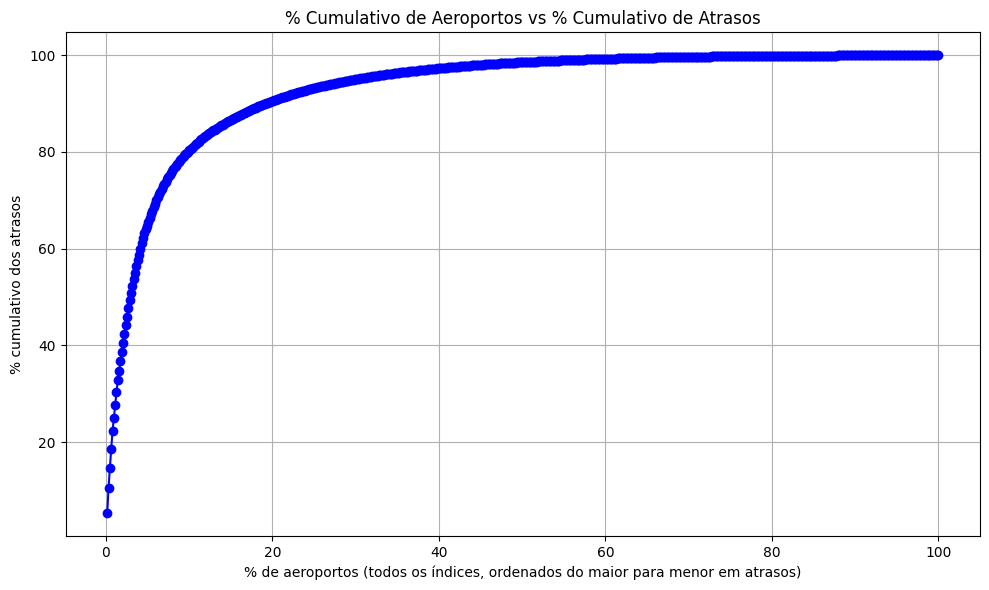

80% dos atrasos estão concentrados nos 62 aeroportos com mais atrasos (9.87%)
90% dos atrasos estão concentrados nos 121 aeroportos com mais atrasos (19.27%)
95% dos atrasos estão concentrados nos 188 aeroportos com mais atrasos (29.94%)


In [23]:
# Verificando corretamente a distribuição dos atrasos entre aeroportos

# Verifica itens estranhos que podem ser a causa de distorção (mas não exclui nada)
print("Quantidade de aeroportos distintos no cálculo:", len(atrasos_total_por_aeroporto.index))

# Para inspecionar: mostra quais índices não tem 3 caracteres (podem ser numéricos, para análise do dado)
aeroporto_index_valido = atrasos_total_por_aeroporto.index.astype(str).str.len() == 3
aeroportos_invalidos = atrasos_total_por_aeroporto[~aeroporto_index_valido]
if not aeroportos_invalidos.empty:
    print("Possíveis aeroportos/anomalias no índice (não removidos):", aeroportos_invalidos)

# Não filtrar, usar todos os resultados
atrasos_ordenados = atrasos_total_por_aeroporto.sort_values(ascending=False)
total_atrasos = atrasos_ordenados.sum()

# Calcula o percentual acumulado de atrasos
percentual_atrasos_acumulado = atrasos_ordenados.cumsum() / total_atrasos * 100

# Percentual acumulado de aeroportos (considera todos os índices)
percentual_aeroportos_acumulado = np.arange(1, len(atrasos_ordenados)+1) / len(atrasos_ordenados) * 100

# Gráfico
plt.figure(figsize=(10,6))
plt.plot(percentual_aeroportos_acumulado, percentual_atrasos_acumulado, marker='o', linestyle='-', color='b')
plt.xlabel('% de aeroportos (todos os índices, ordenados do maior para menor em atrasos)')
plt.ylabel('% cumulativo dos atrasos')
plt.title('% Cumulativo de Aeroportos vs % Cumulativo de Atrasos')
plt.grid(True)
plt.tight_layout()
plt.show()

# Mostra estatística: quantos aeroportos são necessários para atingir 80%/90%/95% dos atrasos
curva_acumulada = percentual_atrasos_acumulado.to_numpy()
for pct in [80, 90, 95]:
    num_airports = int(np.searchsorted(curva_acumulada, pct, side='left') + 1)
    num_airports = min(num_airports, len(atrasos_ordenados))
    print(f"{pct}% dos atrasos estão concentrados nos {num_airports} aeroportos com mais atrasos ({num_airports/len(atrasos_ordenados)*100:.2f}%)")


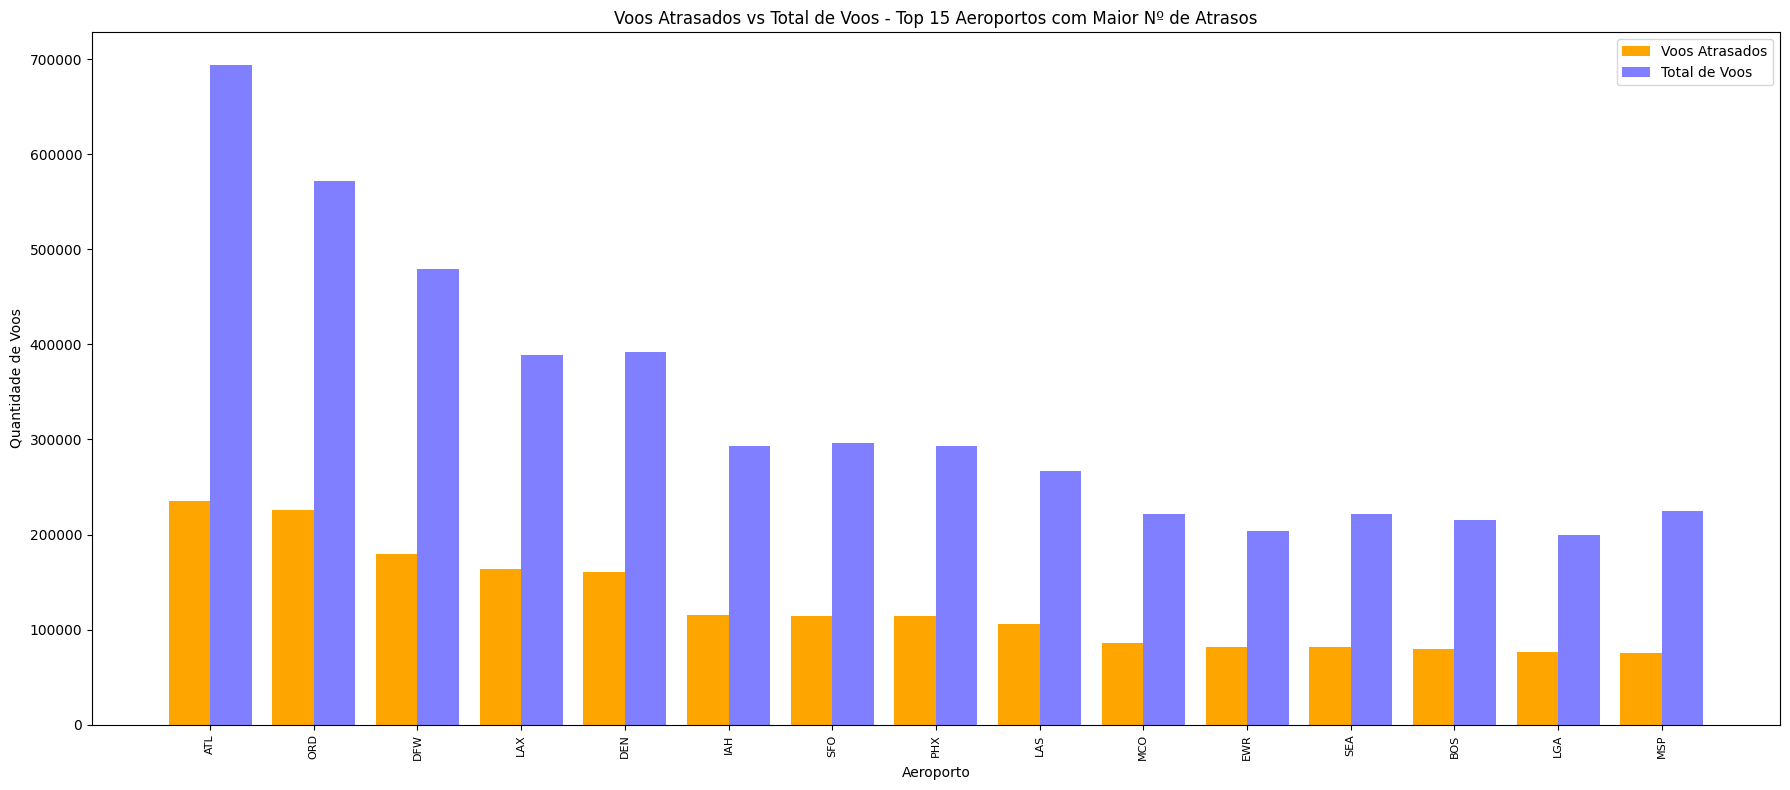

In [24]:
# Top aeroportos por quantidade absoluta de voos atrasados
# (usa a base consolidada: df_aeroportos_stats)

numero_de_aeroportos = 15

# Fallback para o caso de df_aeroportos_stats ainda não ter sido executado
if 'df_aeroportos_stats' not in globals():
    base_df = df_flights_raw.copy()
    aeroportos_partidas = base_df[['ORIGIN_AIRPORT', 'DEPARTURE_DELAY']].rename(
        columns={'ORIGIN_AIRPORT': 'AIRPORT', 'DEPARTURE_DELAY': 'DELAY'}
    )
    aeroportos_chegadas = base_df[['DESTINATION_AIRPORT', 'ARRIVAL_DELAY']].rename(
        columns={'DESTINATION_AIRPORT': 'AIRPORT', 'ARRIVAL_DELAY': 'DELAY'}
    )
    df_aeroportos = pd.concat([aeroportos_partidas, aeroportos_chegadas], ignore_index=True)
    df_aeroportos = df_aeroportos.dropna(subset=['AIRPORT']).copy()
    df_aeroportos['DELAY'] = pd.to_numeric(df_aeroportos['DELAY'], errors='coerce')

    total_voos_por_aeroporto = df_aeroportos.groupby('AIRPORT').size()
    voos_atrasados_por_aeroporto = df_aeroportos[df_aeroportos['DELAY'] > 0].groupby('AIRPORT').size()

    df_aeroportos_stats = pd.DataFrame({
        'Numero_de_Voos': total_voos_por_aeroporto,
        'Voos_Atrasados': voos_atrasados_por_aeroporto
    }).fillna(0)

    df_aeroportos_stats['Numero_de_Voos'] = df_aeroportos_stats['Numero_de_Voos'].astype(int)
    df_aeroportos_stats['Voos_Atrasados'] = df_aeroportos_stats['Voos_Atrasados'].astype(int)
    df_aeroportos_stats['Porcentagem_Atrasos(%)'] = (
        100 * df_aeroportos_stats['Voos_Atrasados'] / df_aeroportos_stats['Numero_de_Voos']
    )

# Usa direto a tabela consistente (Numero_de_Voos >= Voos_Atrasados)
top_aeroportos_maior_qtd = (
    df_aeroportos_stats
    .sort_values('Voos_Atrasados', ascending=False)
    .head(numero_de_aeroportos)
    .copy()
)

indices = np.arange(len(top_aeroportos_maior_qtd))
bar_width = 0.4

# Mesmo eixo para comparação visual correta
plt.figure(figsize=(18, 8))
plt.bar(indices - bar_width/2, top_aeroportos_maior_qtd['Voos_Atrasados'], width=bar_width, color='orange', label='Voos Atrasados')
plt.bar(indices + bar_width/2, top_aeroportos_maior_qtd['Numero_de_Voos'], width=bar_width, color='blue', alpha=0.5, label='Total de Voos')

plt.xlabel('Aeroporto')
plt.ylabel('Quantidade de Voos')
plt.xticks(indices, top_aeroportos_maior_qtd.index, rotation=90, fontsize=8)
plt.legend(loc='upper right')
plt.title(f'Voos Atrasados vs Total de Voos - Top {numero_de_aeroportos} Aeroportos com Maior Nº de Atrasos')
plt.tight_layout()
plt.show()

In [25]:
# Usa a base principal já carregada no notebook
base_df = df_flights_raw.copy()

# Concatenar dados de partidas e chegadas para cada aeroporto
# (cada voo contribui uma vez como origem e uma vez como destino)
aeroportos_partidas = base_df[['ORIGIN_AIRPORT', 'DEPARTURE_DELAY']].rename(
    columns={'ORIGIN_AIRPORT': 'AIRPORT', 'DEPARTURE_DELAY': 'DELAY'}
)
aeroportos_chegadas = base_df[['DESTINATION_AIRPORT', 'ARRIVAL_DELAY']].rename(
    columns={'DESTINATION_AIRPORT': 'AIRPORT', 'ARRIVAL_DELAY': 'DELAY'}
)

# Juntar partidas e chegadas
df_aeroportos = pd.concat([aeroportos_partidas, aeroportos_chegadas], ignore_index=True)

# Limpeza mínima: aeroporto válido e atraso numérico
df_aeroportos = df_aeroportos.dropna(subset=['AIRPORT']).copy()
df_aeroportos['DELAY'] = pd.to_numeric(df_aeroportos['DELAY'], errors='coerce')

# Número total de voos por aeroporto (considerando partidas ou chegadas)
total_voos_por_aeroporto = df_aeroportos.groupby('AIRPORT').size()

# Número de voos atrasados por aeroporto (considerando atraso > 0)
voos_atrasados_por_aeroporto = df_aeroportos[df_aeroportos['DELAY'] > 0].groupby('AIRPORT').size()

# Criar DataFrame final
df_aeroportos_stats = pd.DataFrame({
    'Numero_de_Voos': total_voos_por_aeroporto,
    'Voos_Atrasados': voos_atrasados_por_aeroporto
}).fillna(0)

# Tipos e métrica
df_aeroportos_stats['Numero_de_Voos'] = df_aeroportos_stats['Numero_de_Voos'].astype(int)
df_aeroportos_stats['Voos_Atrasados'] = df_aeroportos_stats['Voos_Atrasados'].astype(int)
df_aeroportos_stats['Porcentagem_Atrasos(%)'] = (
    100 * df_aeroportos_stats['Voos_Atrasados'] / df_aeroportos_stats['Numero_de_Voos']
)

# Visualização rápida
df_aeroportos_stats = df_aeroportos_stats.sort_values('Porcentagem_Atrasos(%)', ascending=False)
display(df_aeroportos_stats.head(10))

,Numero_de_Voos,Voos_Atrasados,Porcentagem_Atrasos(%)
AIRPORT,,,
14025,26,17,65.384615
GUM,668,424,63.473054
14222,18,10,55.555556
GST,154,85,55.194805
ILG,198,109,55.050505
PBG,563,293,52.042629
13964,72,37,51.388889
15070,124,58,46.774194
BQN,2686,1245,46.351452


In [26]:
df_aeroportos['AIRPORT'].nunique()

629

In [27]:
#Calculando o quanto de atraso X o quanto as colunas delay informam

# Conferindo a lógica para calcular atrasos previstos e imprevistos

atraso_previsto = 0
atraso_imprevisto = 0

# Corrigindo: iterar nas linhas do DataFrame de verdade, e usando .loc ou .iloc
for idx, row in df_flights_raw.iterrows():
    # Verifica se há pelo menos um valor de atraso identificado (a lógica pode ser refinada, aqui tomamos AIRLINE_DELAY como referência)
    # Pode-se trocar por: if not pd.isna(row['AIRLINE_DELAY']):
    if pd.notnull(row['AIRLINE_DELAY']):
        # Soma considerando NaNs como zero
        atraso_calculado = sum([
            row.get('AIR_SYSTEM_DELAY'),
            row.get('SECURITY_DELAY'),
            row.get('AIRLINE_DELAY'),
            row.get('LATE_AIRCRAFT_DELAY'),
            row.get('WEATHER_DELAY'),
        ])
        atraso_total = row['ARRIVAL_DELAY'] if pd.notnull(row['ARRIVAL_DELAY']) else 0
        # Pode ser interessante arredondar para lidar com floats
        if atraso_calculado == atraso_total:
            atraso_previsto += 1
        else:
            atraso_imprevisto += 1

print(f"atrasos casusados por uma das 4 colunas {atraso_previsto}")
print(f"atrasos causados por outras causas {atraso_imprevisto}")

atrasos casusados por uma das 4 colunas 1063439
atrasos causados por outras causas 0


In [28]:
# Contar número de linhas onde as colunas de causas de atraso NÃO são NaN (todas presentes)
colunas_delay = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]
num_linhas_sem_nan = df_flights_raw[colunas_delay].notna().all(axis=1).sum()
print(num_linhas_sem_nan)

1063439


In [29]:
# Remover todas as linhas onde as colunas delay NÃO são NaN (ou seja, manter só as que são TODOS NaN nessas colunas)
colunas_delay = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]
df_flights_limpas = df_flights_raw[df_flights_raw[colunas_delay].isna().all(axis=1)].copy()
print(df_flights_limpas.shape)

(4755640, 31)


In [30]:
# Agora vamos excluir as colunas de causas de atraso e mais algumas não relevantes do dataframe df_flights_limpas
colunas_excluidas = [
    'FLIGHT_NUMBER',
    'TAIL_NUMBER',
    'DEPARTURE_TIME',
    'SCHEDULED_TIME',
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY',
    'YEAR',
    'DAY',
    'DIVERTED',
    'CANCELLED',
    'CANCELLATION_REASON',
    'ARRIVAL_TIME'
]
df_flights_limpas = df_flights_limpas.drop(columns=colunas_excluidas)


In [31]:
df_flights_limpas.shape

(4755640, 16)

In [32]:
df_flights_limpas.head()

,MONTH,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_DELAY
0,1,4,AS,ANC,SEA,5,-11.0,21.0,15.0,194.0,169.0,1448,404.0,4.0,430,-22.0
1,1,4,AA,LAX,PBI,10,-8.0,12.0,14.0,279.0,263.0,2330,737.0,4.0,750,-9.0
2,1,4,US,SFO,CLT,20,-2.0,16.0,34.0,293.0,266.0,2296,800.0,11.0,806,5.0
3,1,4,AA,LAX,MIA,20,-5.0,15.0,30.0,281.0,258.0,2342,748.0,8.0,805,-9.0
4,1,4,AS,SEA,ANC,25,-1.0,11.0,35.0,215.0,199.0,1448,254.0,5.0,320,-21.0


In [33]:
min_arrival_delay = df_flights_limpas['ARRIVAL_DELAY'].min()
max_arrival_delay = df_flights_limpas['ARRIVAL_DELAY'].max()
print(f"Valor mínimo de ARRIVAL_DELAY: {min_arrival_delay}")
print(f"Valor máximo de ARRIVAL_DELAY: {max_arrival_delay}")

Valor mínimo de ARRIVAL_DELAY: -87.0
Valor máximo de ARRIVAL_DELAY: 14.0


In [34]:
# Contar valores positivos na coluna ARRIVAL_DELAY
num_atrasos = (df_flights_limpas['ARRIVAL_DELAY'] > 0).sum()
print(f"Quantidade de registros com ARRIVAL_DELAY positivo (atrasos): {num_atrasos}")

Quantidade de registros com ARRIVAL_DELAY positivo (atrasos): 1023457


In [35]:
df_flights_limpas['BOL_DELAYED'] = (df_flights_limpas['ARRIVAL_DELAY'] >= 0).astype(int)

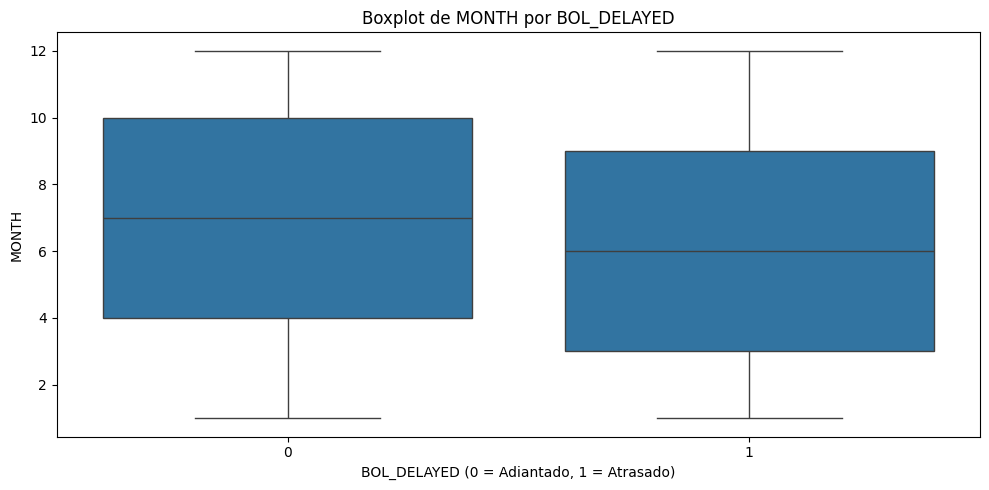

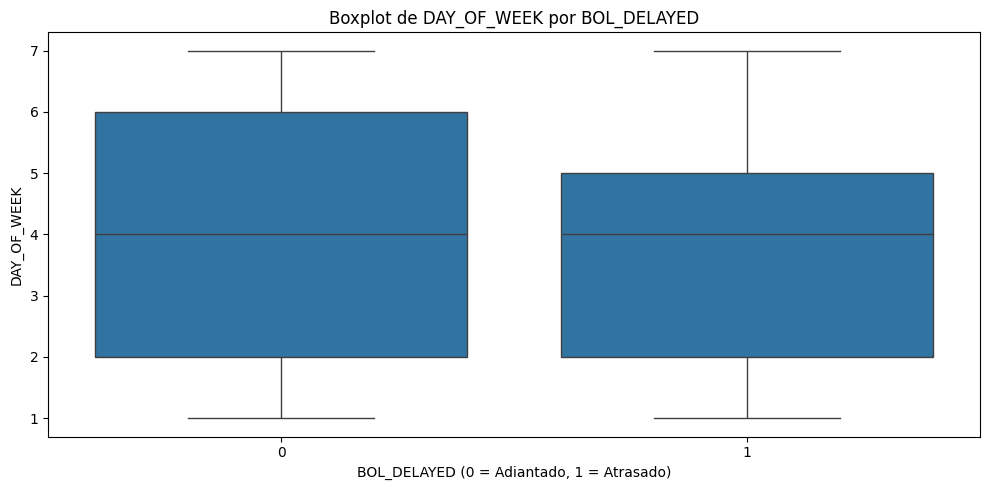

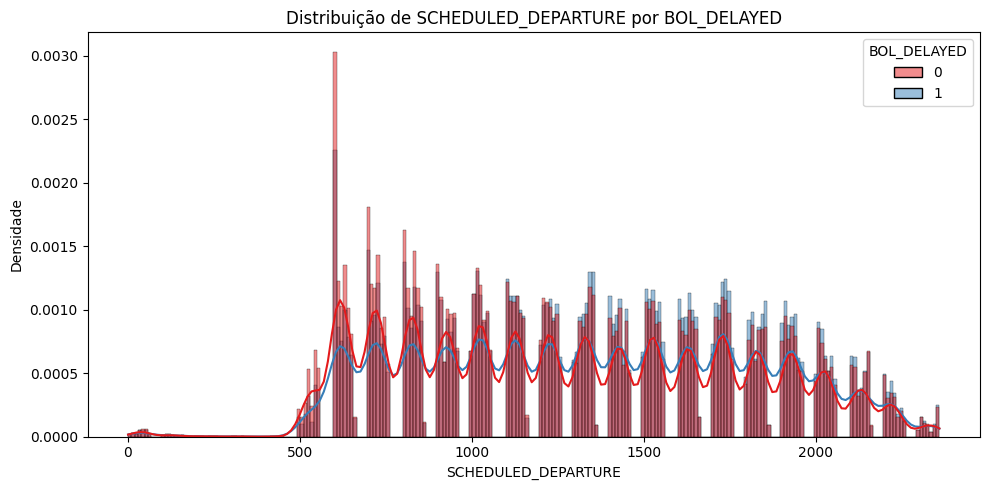

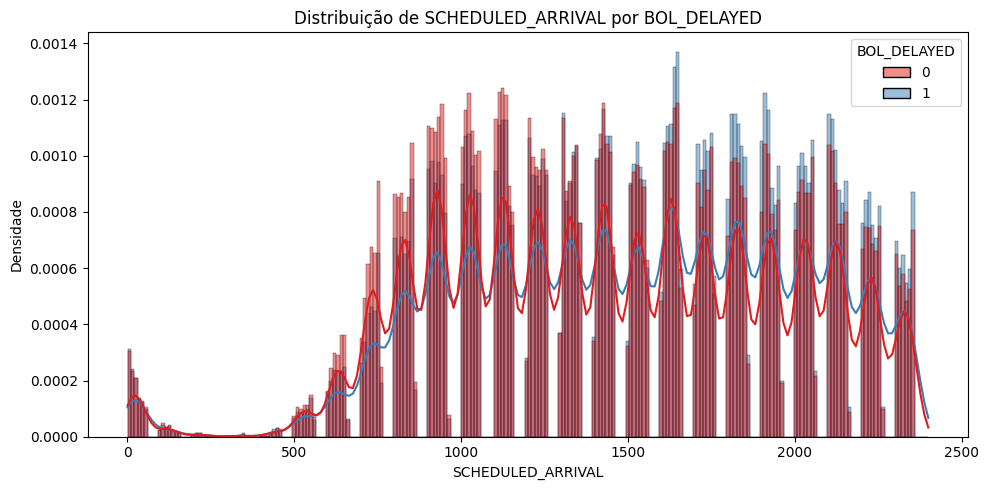

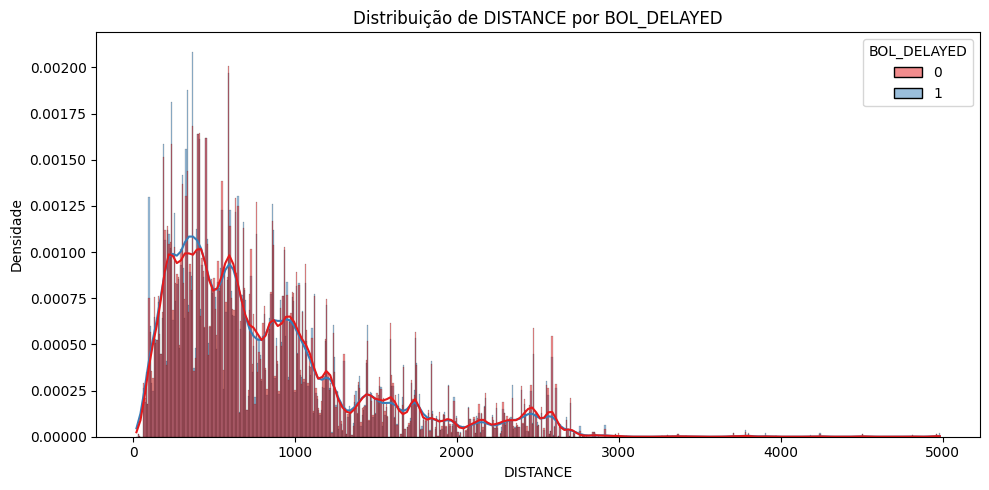

In [36]:
# Lista de colunas para relacionar com BOL_DELAYED
colunas_para_analisar = ['MONTH', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL', 'DISTANCE']

for coluna in colunas_para_analisar:
    plt.figure(figsize=(10,5))
    if df_flights_limpas[coluna].nunique() < 20:  # Se for categórica
        sns.boxplot(x='BOL_DELAYED', y=coluna, data=df_flights_limpas)
        plt.xlabel("BOL_DELAYED (0 = Adiantado, 1 = Atrasado)")
        plt.ylabel(coluna)
        plt.title(f"Boxplot de {coluna} por BOL_DELAYED")
    else:  # Se for contínua
        sns.histplot(
            data=df_flights_limpas, 
            x=coluna, 
            hue='BOL_DELAYED', 
            kde=True, 
            stat="density", 
            common_norm=False, 
            palette='Set1'
        )
        plt.xlabel(coluna)
        plt.ylabel("Densidade")
        plt.title(f"Distribuição de {coluna} por BOL_DELAYED")
    plt.tight_layout()
    plt.show()


Top aeroportos por proporção de voos atrasados:



,Numero_de_Voos,Voos_Atrasados,Proporcao_Atrasos
AIRPORT,,,
14025,26,17,0.653846
GUM,668,424,0.634731
14222,18,10,0.555556
GST,154,85,0.551948
ILG,198,109,0.550505
PBG,563,293,0.520426
13964,72,37,0.513889
15070,124,58,0.467742
BQN,2686,1245,0.463515


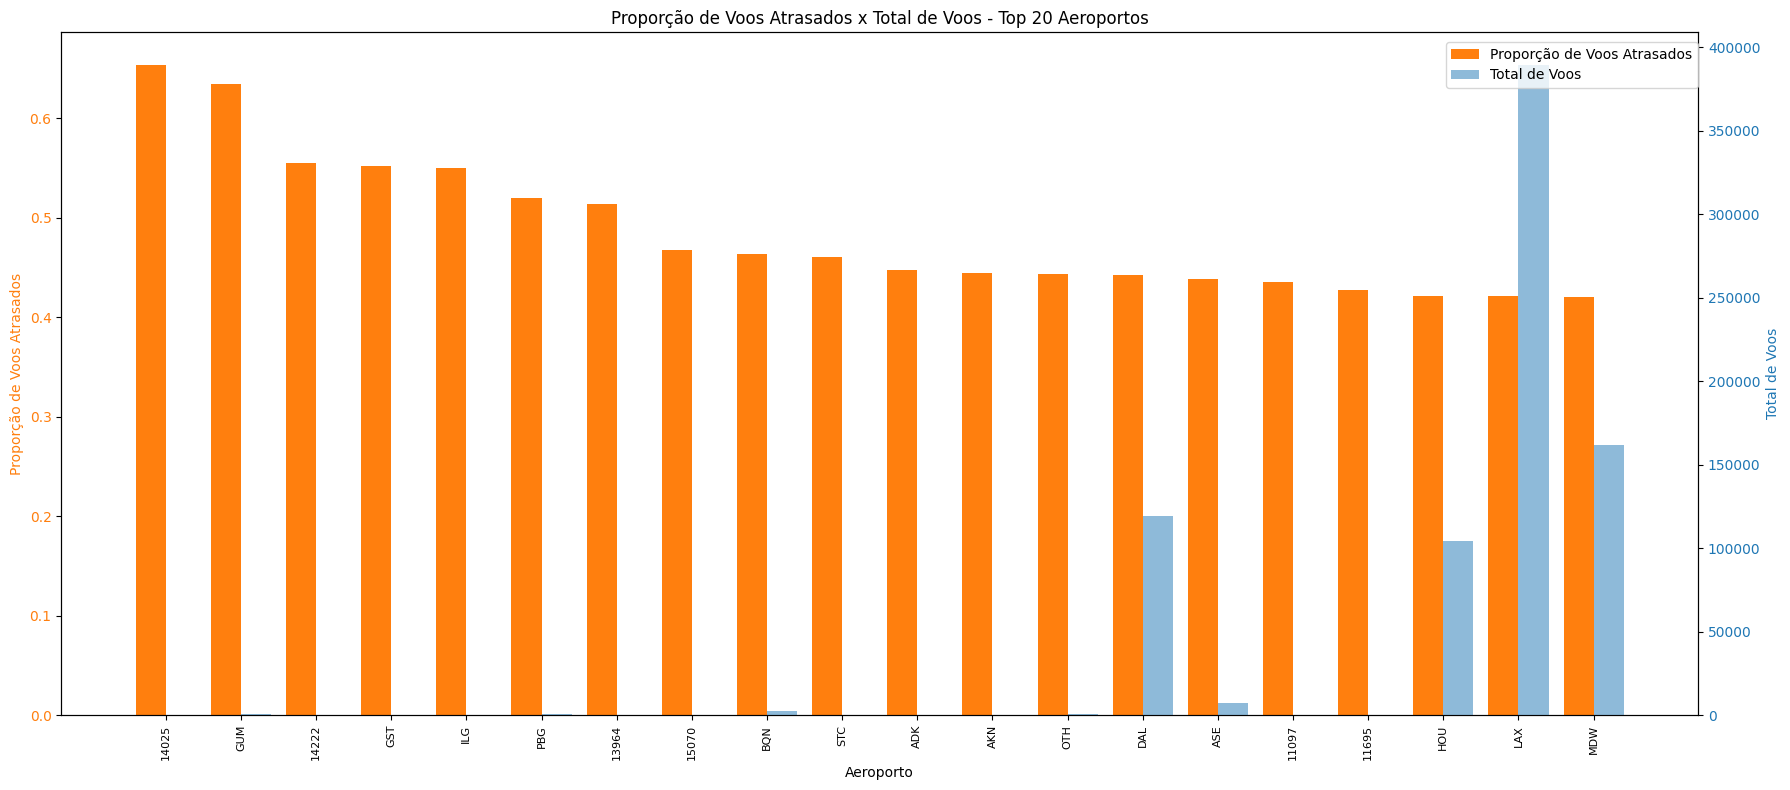


Proporção de voos atrasados por companhia aérea:



,Numero_de_Voos,Voos_Atrasados,Proporcao_Atrasos
AIRLINE,,,
HA,67654,24878,0.367724
NK,83158,25079,0.301583
F9,67266,19647,0.292079
VX,50125,13988,0.279062
US,162166,44275,0.273023
OO,480558,129052,0.268546
AS,150169,38925,0.259208
WN,1025229,263445,0.256962
EV,462793,117267,0.253390


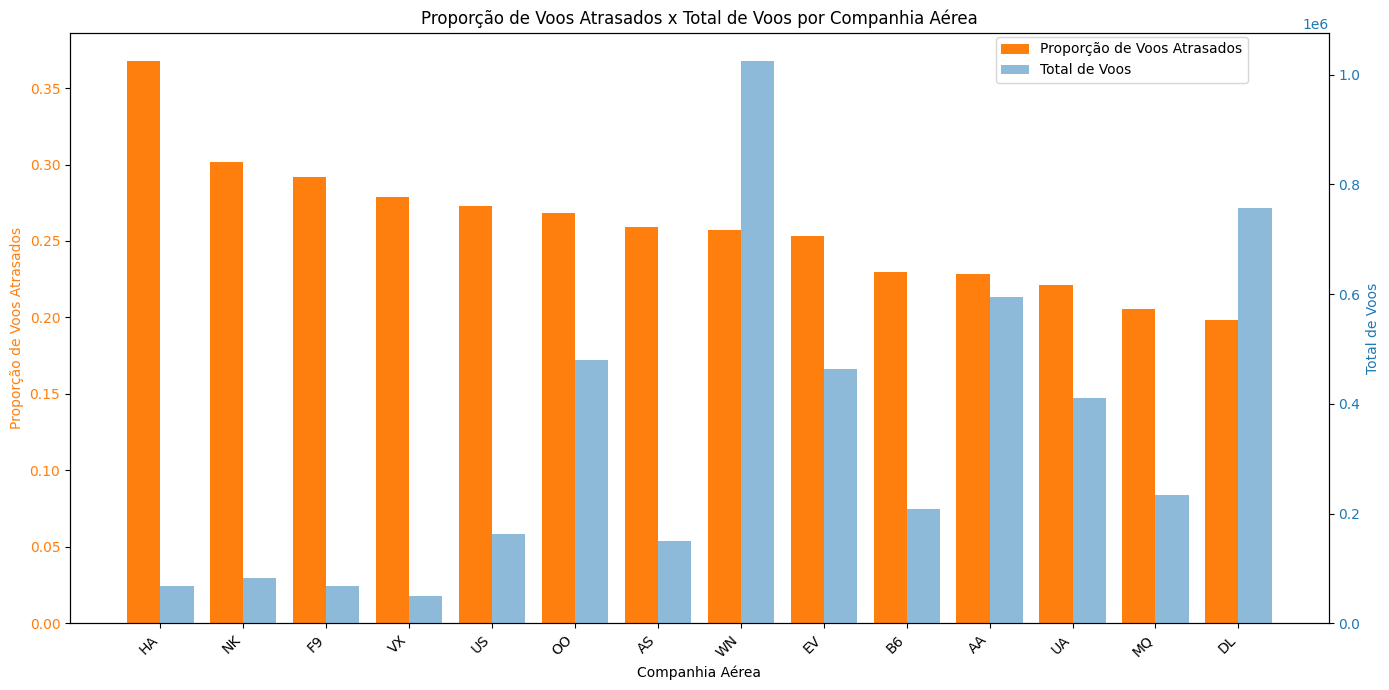

In [37]:
# Gráfico do modelo sugerido para aeroportos

numero_de_aeroportos = 20

# Calcula estatísticas de atraso por aeroporto caso ainda não existam
if 'df_aeroportos_stats' not in globals():
    base_df = df_flights_limpas.copy()
    aeroportos_partidas = base_df[['ORIGIN_AIRPORT', 'BOL_DELAYED']].rename(
        columns={'ORIGIN_AIRPORT': 'AIRPORT', 'BOL_DELAYED': 'DELAYED'}
    )
    aeroportos_chegadas = base_df[['DESTINATION_AIRPORT', 'BOL_DELAYED']].rename(
        columns={'DESTINATION_AIRPORT': 'AIRPORT', 'BOL_DELAYED': 'DELAYED'}
    )
    df_aeroportos = pd.concat([aeroportos_partidas, aeroportos_chegadas], ignore_index=True)
    df_aeroportos = df_aeroportos.dropna(subset=['AIRPORT']).copy()
    df_aeroportos['DELAYED'] = pd.to_numeric(df_aeroportos['DELAYED'], errors='coerce')

    total_voos_por_aeroporto = df_aeroportos.groupby('AIRPORT').size()
    voos_atrasados_por_aeroporto = df_aeroportos[df_aeroportos['DELAYED'] > 0].groupby('AIRPORT').size()
    prop_atrasos = voos_atrasados_por_aeroporto / total_voos_por_aeroporto

    df_aeroportos_stats = pd.DataFrame({
        'Numero_de_Voos': total_voos_por_aeroporto,
        'Voos_Atrasados': voos_atrasados_por_aeroporto,
        'Proporcao_Atrasos': prop_atrasos
    }).fillna(0)

    df_aeroportos_stats['Numero_de_Voos'] = df_aeroportos_stats['Numero_de_Voos'].astype(int)
    df_aeroportos_stats['Voos_Atrasados'] = df_aeroportos_stats['Voos_Atrasados'].astype(int)

else:
    df_aeroportos_stats = df_aeroportos_stats.copy()
    if 'Proporcao_Atrasos' not in df_aeroportos_stats.columns:
        df_aeroportos_stats['Proporcao_Atrasos'] = (
            df_aeroportos_stats['Voos_Atrasados'] / df_aeroportos_stats['Numero_de_Voos']
        )

# Seleção dos top aeroportos
top_aeroportos_maior_prop = (
    df_aeroportos_stats
    .sort_values('Proporcao_Atrasos', ascending=False)
    .head(numero_de_aeroportos)
    .copy()
)

# Exibe tabela dos aeroportos antes do gráfico
print("\nTop aeroportos por proporção de voos atrasados:\n")
display(top_aeroportos_maior_prop[['Numero_de_Voos', 'Voos_Atrasados', 'Proporcao_Atrasos']])

indices = np.arange(len(top_aeroportos_maior_prop))
bar_width = 0.4

fig, ax1 = plt.subplots(figsize=(18, 8))
color1 = 'tab:orange'
color2 = 'tab:blue'

# Barras para proporção de voos atrasados (eixo esquerdo)
ax1.bar(indices - bar_width/2, top_aeroportos_maior_prop['Proporcao_Atrasos'], width=bar_width, color=color1, label='Proporção de Voos Atrasados')
ax1.set_ylabel('Proporção de Voos Atrasados', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(indices)
ax1.set_xticklabels(top_aeroportos_maior_prop.index, rotation=90, fontsize=8)
ax1.set_xlabel('Aeroporto')

# Segundo eixo para o total de voos (eixo direito)
ax2 = ax1.twinx()
ax2.bar(indices + bar_width/2, top_aeroportos_maior_prop['Numero_de_Voos'], width=bar_width, color=color2, alpha=0.5, label='Total de Voos')
ax2.set_ylabel('Total de Voos', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title(f'Proporção de Voos Atrasados x Total de Voos - Top {numero_de_aeroportos} Aeroportos')
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
plt.tight_layout()
plt.show()

# Versão para companhias aéreas

companhias_group = (
    df_flights_limpas
    .groupby("AIRLINE")
    .agg(
        Numero_de_Voos = ("BOL_DELAYED", "count"),
        Voos_Atrasados = ("BOL_DELAYED", lambda x: (x > 0).sum())
    )
)
companhias_group["Proporcao_Atrasos"] = companhias_group["Voos_Atrasados"] / companhias_group["Numero_de_Voos"]

companhias_ordenadas = companhias_group.sort_values("Proporcao_Atrasos", ascending=False)

# Exibe tabela das companhias antes do gráfico
print("\nProporção de voos atrasados por companhia aérea:\n")
display(companhias_ordenadas[['Numero_de_Voos', 'Voos_Atrasados', 'Proporcao_Atrasos']])

indices = np.arange(len(companhias_ordenadas))
bar_width = 0.4

fig, ax1 = plt.subplots(figsize=(14, 7))
color1 = 'tab:orange'
color2 = 'tab:blue'

ax1.bar(indices - bar_width/2, companhias_ordenadas["Proporcao_Atrasos"], width=bar_width, color=color1, label='Proporção de Voos Atrasados')
ax1.set_ylabel('Proporção de Voos Atrasados', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(indices)
ax1.set_xticklabels(companhias_ordenadas.index, rotation=45, ha='right', fontsize=10)
ax1.set_xlabel('Companhia Aérea')

ax2 = ax1.twinx()
ax2.bar(indices + bar_width/2, companhias_ordenadas["Numero_de_Voos"], width=bar_width, color=color2, alpha=0.5, label='Total de Voos')
ax2.set_ylabel('Total de Voos', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Proporção de Voos Atrasados x Total de Voos por Companhia Aérea')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.95))
plt.tight_layout()
plt.show()



In [38]:
# Vamos remover as colunas de companhias aéreas ("AIRLINE") e as duas de aeroportos ("ORIGIN_AIRPORT", "DESTINATION_AIRPORT")

colunas_para_remover = ["MONTH","DAY_OF_WEEK","AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]

# Garante que só remove se a coluna existir (evita erro caso já estejam removidas ou nomes diferentes)
colunas_presentes = [col for col in colunas_para_remover if col in df_flights_limpas.columns]
df_flights_limpas = df_flights_limpas.drop(columns=colunas_presentes)

# Exibe as primeiras linhas para checagem
df_flights_limpas.head()

,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,BOL_DELAYED
0,5,-11.0,21.0,15.0,194.0,169.0,1448,404.0,4.0,430,-22.0,0
1,10,-8.0,12.0,14.0,279.0,263.0,2330,737.0,4.0,750,-9.0,0
2,20,-2.0,16.0,34.0,293.0,266.0,2296,800.0,11.0,806,5.0,1
3,20,-5.0,15.0,30.0,281.0,258.0,2342,748.0,8.0,805,-9.0,0
4,25,-1.0,11.0,35.0,215.0,199.0,1448,254.0,5.0,320,-21.0,0


In [39]:
df_flights_limpas.shape

(4755640, 12)

In [40]:
# Salva o DataFrame df_flights_limpas como CSV (sem o índice) para uso posterior
df_flights_limpas.to_csv("data/flights_limpas.csv", index=False)